# Mini Project 9 :- AI-Based Credit Card Fraud Detection System

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# V1 to V28 kya hain? 
# Ye original data nahi hai
# Ye generated (badle hue) features hain
# Inko banaya gaya hai ek technique se jiska naam hai -- > PCA (Principal Component Analysis)
# PCA ek technique hai jo bahut saare original columns ko compress karke new columns bana deta hai
# mtlb original columns ko compress karke “pattern-based columns” bana diye

# “V1 to V28 are PCA-transformed features. 
# PCA converts original sensitive transaction data into new components that represent patterns while hiding actual customer information.”

In [5]:
df.shape

(284807, 31)

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.duplicated().sum()

np.int64(1081)

In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.shape

(283726, 31)

In [12]:
# Class Distribution Check

# fraud vs normal check --> 0 - normal, 1 - fraud
check = df['Class'].value_counts()
check

Class
0    283253
1       473
Name: count, dtype: int64

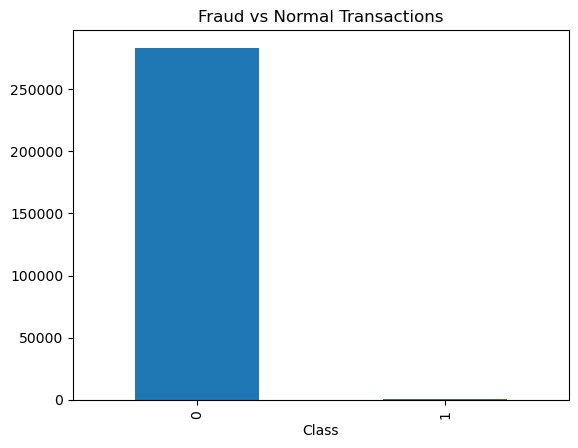

In [13]:
# class distribution plot
check.plot(kind='bar')
plt.title("Fraud vs Normal Transactions")
plt.show()

In [14]:
# feature selection

# input(X)
X = df.drop('Class', axis=1)
# output(y)
y = df['Class']

# Train-Test Split

In [15]:
# data split kar rahe hain training aur testing ke liye
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data Scaling

In [16]:
# scaling kar rahe hain taaki sab features same range me aa jaye
# Logistic Regression distance based hota hai, Different scale (Amount vs V1-V28) problem create karta hai...isliye Scaling..
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
# logistic regression model use kar rahe hain  qki ye binary classification problem hai
model = LogisticRegression(max_iter=1000, class_weight = "balanced")   # Class imbalance handle kar sakta hai (class_weight)

# model ko train karna
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
# model test data pe prediction kar raha hai
y_pred = model.predict(X_test_scaled)

# Evaluation

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [22]:
# accuracy check
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9776019455115779


In [23]:
# confusion matrix (real performance samajhne ke liye)
print(confusion_matrix(y_test, y_pred))

[[55395  1261]
 [   10    80]]


In [24]:
# detailed report (precision, recall, f1-score)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.06      0.89      0.11        90

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.55     56746
weighted avg       1.00      0.98      0.99     56746



# Confusion matrix visualization

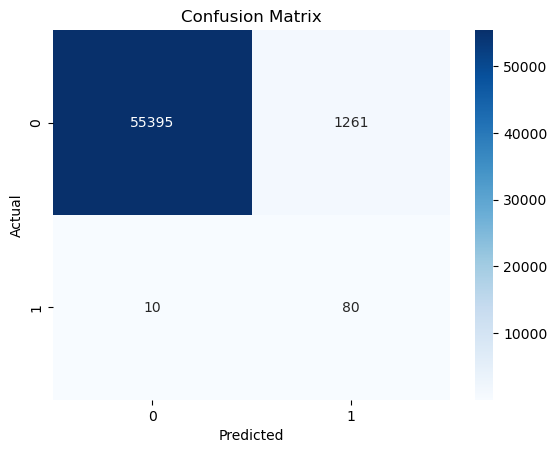

In [25]:
cm = confusion_matrix(y_test, y_pred)

# confusion matrix ko better samajhne ke liye heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Random Forest Classifier

In [26]:
# “Random Forest = Many Decision Trees + Voting system”

# WHY RANDOM FOREST?

# Multiple trees = better accuracy
# Overfitting kam hota hai
# Complex fraud patterns detect karta hai

In [27]:
from sklearn.ensemble import RandomForestClassifier

# multiple decision trees bana ke model train 
rf = RandomForestClassifier(n_estimators=10, random_state=42)
rf.fit(X_train, y_train)

# prediction
y_pred_rf = rf.predict(X_test)

In [30]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9995065731505305


In [31]:
# “We used Logistic Regression as a baseline model and
# Random Forest as an advanced ensemble model to improve fraud detection accuracy and handle complex patterns in financial transactions.”

# “In fraud detection, recall is more important than accuracy
# Recall batata hai: Actual fraud transactions me se model ne kitni fraud transactions ko correctly identify kiya.